# KMeans com Split Temporal

Notebook para rodar o KMeans na base final do projeto usando o corte temporal

A logica aqui e:
- carregar o CSV final;
- remover colunas com vazamento de informacao e colunas de data que nao entram no modelo;
- separar treino e teste por data;
- padronizar apenas com o treino;
- escolher o melhor `k` pelo metodo do cotovelo;
- treinar o KMeans final e avaliar os clusters no periodo de teste.

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import mode

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


In [61]:
csv_path = Path(r"C:\Users\otavi\OneDrive\Desktop\last-mile-tcc\backend\tabela_final\part-00000-bc8041e1-56a7-4223-b839-8474dfbae85d-c000.csv")
df = pd.read_csv(csv_path)

if "delivered_on_time" not in df.columns:
    raise ValueError("A coluna alvo 'delivered_on_time' nao foi encontrada no CSV.")

# Colunas removidas logo no inicio do preparo porque nao entram no KMeans.
columns_to_drop = [
    'seller_geolocation_lat',
    'seller_geolocation_lng',
    'customer_geolocation_lat',
    'customer_geolocation_lng',
    'order_delivered_customer_date',
    'order_delivered_carrier_date',
    'review_score',
    'approval_time_hours',
    'handling_time_hours',
    'shipping_delay_hours',
    'seller_total_rainfall_period_mm',
    'seller_max_rain_intensity_mm_h',
    'seller_max_wind_gust_period_ms',
    'seller_interval_code',
    'seller_rain_class_code',
    'seller_wind_class_code',
    'seller_accumulated_rainfall_3_days_mm',
    'seller_is_heavy_rain',
    'seller_is_strong_wind',
    'customer_total_rainfall_period_mm',
    'customer_max_rain_intensity_mm_h',
    'customer_max_wind_gust_period_ms',
    'customer_interval_code',
    'customer_rain_class_code',
    'customer_wind_class_code',
    'customer_accumulated_rainfall_3_days_mm',
    'customer_is_heavy_rain',
    'customer_is_strong_wind',
    'seller_meso_metropolitana_de_sao_paulo',
    'seller_meso_araraquara',
    'seller_meso_piracicaba',
    'seller_meso_ribeirao_preto',
    'seller_meso_sao_jose_do_rio_preto',
    'seller_meso_campinas',
    'seller_meso_vale_do_paraiba_paulista',
    'seller_meso_macro_metropolitana_paulista',
    'seller_meso_bauru',
    'seller_meso_presidente_prudente',
    'seller_meso_marilia',
    'seller_meso_assis',
    'seller_meso_aracatuba',
    'seller_meso_litoral_sul_paulista',
    'seller_meso_itapetininga',
    'customer_meso_metropolitana_de_sao_paulo',
    'customer_meso_piracicaba',
    'customer_meso_campinas',
    'customer_meso_vale_do_paraiba_paulista',
    'customer_meso_ribeirao_preto',
    'customer_meso_sao_jose_do_rio_preto',
    'customer_meso_macro_metropolitana_paulista',
    'customer_meso_bauru',
    'customer_meso_araraquara',
    'customer_meso_presidente_prudente',
    'customer_meso_marilia',
    'customer_meso_assis',
    'customer_meso_aracatuba',
    'customer_meso_itapetininga',
    'customer_meso_litoral_sul_paulista'
]

df_model = df.drop(columns=columns_to_drop, errors="ignore").copy()

split_date_candidates = [
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_purchase_timestamp",
]

date_col_name = next((col for col in split_date_candidates if col in df.columns), None)
if date_col_name is None:
    raise ValueError("Nenhuma coluna de data disponivel foi encontrada para o split temporal.")

date_col = pd.to_datetime(df[date_col_name], utc=True, errors="coerce")
valid_mask = date_col.notna()

# Classe positiva: atraso = 1, nao atraso = 0.
y = (~df["delivered_on_time"].astype(bool)).astype(int)

feature_df = df_model.drop(columns=["delivered_on_time"], errors="ignore")
feature_df = feature_df.select_dtypes(include=["number", "bool"]).copy()
for column in feature_df.select_dtypes(include=["bool"]).columns:
    feature_df[column] = feature_df[column].astype(int)

feature_df = feature_df.loc[valid_mask].copy()
y = y.loc[valid_mask].copy()
date_col = date_col.loc[valid_mask].copy()

split_date = pd.to_datetime("2018-07-01", utc=True)
train_mask = date_col < split_date
test_mask = date_col >= split_date

X_train_raw = feature_df.loc[train_mask].copy()
X_test_raw = feature_df.loc[test_mask].copy()
y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

print(f"Coluna temporal usada no split: {date_col_name}")
print(f"Total de registros validos: {len(feature_df):,}\n")
train_count = len(X_train_raw)
test_count = len(X_test_raw)
train_delays = int(y_train.sum())
test_delays = int(y_test.sum())
print(f"Treino (ate Jun/2018): {train_count:,} ({train_count/len(feature_df):.2%})")
print(f" - Atrasos no Treino: {train_delays:,} ({train_delays/train_count:.2%} do treino)")
print()
print(f"Teste (Jul/2018 em diante): {test_count:,} ({test_count/len(feature_df):.2%})")
print(f" - Atrasos no Teste: {test_delays:,} ({test_delays/test_count:.2%} do teste)")
print(f"\nNumero de features numericas: {X_train_raw.shape[1]}")


Coluna temporal usada no split: order_delivered_carrier_date
Total de registros validos: 33,820

Treino (ate Jun/2018): 28,706 (84.88%)
 - Atrasos no Treino: 1,425 (4.96% do treino)

Teste (Jul/2018 em diante): 5,114 (15.12%)
 - Atrasos no Teste: 613 (11.99% do teste)

Numero de features numericas: 12


In [62]:
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train_raw),
    columns=X_train_raw.columns,
    index=X_train_raw.index,
)
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test_raw),
    columns=X_test_raw.columns,
    index=X_test_raw.index,
)

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imputed),
    columns=X_train_imputed.columns,
    index=X_train_imputed.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imputed),
    columns=X_test_imputed.columns,
    index=X_test_imputed.index,
)

print(f"Shape treino padronizado: {X_train_scaled.shape}")
print(f"Shape teste padronizado: {X_test_scaled.shape}")
print("Primeiras 5 colunas do conjunto final:")
display(X_train_scaled.head())

Shape treino padronizado: (28706, 12)
Shape teste padronizado: (5114, 12)
Primeiras 5 colunas do conjunto final:


,holiday_at_shipping,delivery_time_days,purchase_hour,purchase_day_of_week,is_weekend,price,freight_value,product_weight_g,volume_cm3,distance_km,same_city,month
0,-0.0318,-0.353063,-0.136109,1.113996,1.746409,-0.510359,-1.786994,-0.528927,-0.681709,-0.091645,-0.399036,-1.424204
1,-0.0318,-0.353063,-0.136109,1.113996,1.746409,-0.510359,-1.786994,-0.528927,-0.681709,-0.091645,-0.399036,-1.424204
2,-0.0318,-0.353063,-0.136109,1.113996,1.746409,-0.510359,-1.786994,-0.528927,-0.681709,-0.091645,-0.399036,-1.424204
3,-0.0318,-0.353063,-0.136109,1.113996,1.746409,-0.510359,-1.786994,-0.528927,-0.681709,-0.091645,-0.399036,-1.424204
4,-0.0318,0.532551,-2.393055,1.645101,1.746409,1.182085,0.060072,-0.419980,-0.603889,-0.490442,-0.399036,-1.127075


--- METODO DO COTOVELO ---
Cotovelo detectado automaticamente: k=5
Numero de clusters adotado para a analise: k=2 (atraso vs nao atraso)


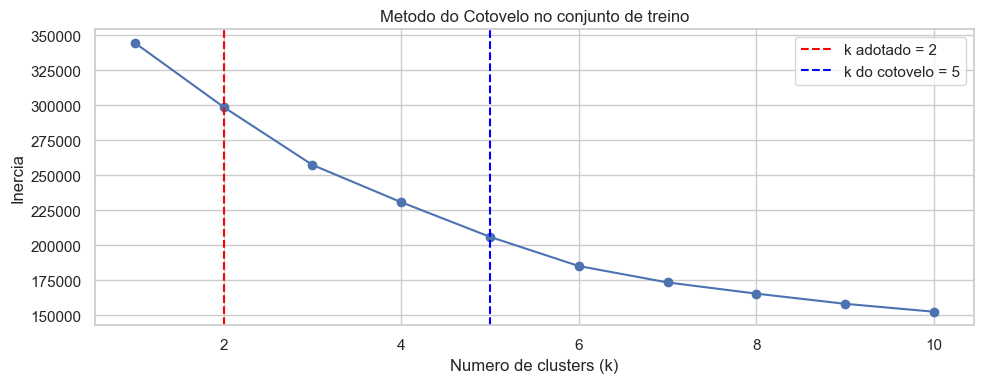

In [63]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_train_scaled)
    inertias.append(model.inertia_)

p1 = np.array([k_range[0], inertias[0]])
p2 = np.array([k_range[-1], inertias[-1]])
line_vec = p2 - p1
line_norm = np.linalg.norm(line_vec)
distances = []

for idx, k in enumerate(k_range):
    p0 = np.array([k, inertias[idx]])
    point_vec = p1 - p0
    distance = abs(line_vec[0] * point_vec[1] - line_vec[1] * point_vec[0]) / line_norm
    distances.append(distance)

elbow_k = k_range[np.argmax(distances)]
optimal_k = 2

print("--- METODO DO COTOVELO ---")
print(f"Cotovelo detectado automaticamente: k={elbow_k}")
print("Numero de clusters adotado para a analise: k=2 (atraso vs nao atraso)")

plt.figure(figsize=(10, 4))
plt.plot(list(k_range), inertias, marker="o")
plt.axvline(optimal_k, color="red", linestyle="--", label=f"k adotado = {optimal_k}")
plt.axvline(elbow_k, color="blue", linestyle="--", label=f"k do cotovelo = {elbow_k}")
plt.title("Metodo do Cotovelo no conjunto de treino")
plt.xlabel("Numero de clusters (k)")
plt.ylabel("Inercia")
plt.legend()
plt.tight_layout()
plt.show()

In [64]:
def avaliar_kmeans(k, X_train, X_test, y_train, y_test):
    print(f"{'='*50}")
    print(f" AVALIACAO DO MODELO KMEANS COM K = {k}".center(50))
    print(f"{'='*50}\n")
    
    # 1. Treinamento
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    train_clusters = kmeans_model.fit_predict(X_train)
    test_clusters = kmeans_model.predict(X_test)
    
    # 2. Mapeamento de clusters (regra: taxa > global_delay_rate = Atraso)
    cluster_rows = []
    global_delay_rate = float(y_train.mean())
    for cluster_id in range(k):
        cluster_mask = train_clusters == cluster_id
        cluster_size = int(np.sum(cluster_mask))
        if cluster_size == 0:
            continue
        delay_rate = float(y_train.loc[cluster_mask].mean())
        cluster_rows.append({
            "cluster": cluster_id,
            "tamanho": cluster_size,
            "taxa_atraso": delay_rate,
            "regra": 1 if delay_rate >= global_delay_rate else 0,
        })
    
    cluster_summary = pd.DataFrame(cluster_rows).sort_values("taxa_atraso", ascending=False).reset_index(drop=True)
    cluster_to_class = dict(zip(cluster_summary["cluster"], cluster_summary["regra"]))
    mapped_test_clusters = np.array([cluster_to_class.get(c, 0) for c in test_clusters])
    
    print(f"Taxa global de atraso no treino: {global_delay_rate:.2%}")
    print("Resumo por cluster:")
    display(cluster_summary.round(4))
    
    # 3. Metricas
    def res_metricas(y_true, y_pred):
        return {
            "accuracy": accuracy_score(y_true, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "precision_atraso": precision_score(y_true, y_pred, zero_division=0),
            "recall_atraso": recall_score(y_true, y_pred, zero_division=0),
            "f1_atraso": f1_score(y_true, y_pred, zero_division=0),
        }

    metricas_teste = res_metricas(y_test, mapped_test_clusters)
    print("\nResumo final do teste:")
    print(f"- Accuracy: {metricas_teste['accuracy']:.4f}")
    print(f"- Balanced Accuracy: {metricas_teste['balanced_accuracy']:.4f}")
    print(f"- Precision atraso: {metricas_teste['precision_atraso']:.4f}")
    print(f"- Recall atraso: {metricas_teste['recall_atraso']:.4f}")
    print(f"- F1 atraso: {metricas_teste['f1_atraso']:.4f}\n")
    
    # 4. Graficos Lado a Lado (Matriz de Confusao e PCA)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Matriz de Confusao
    cm = confusion_matrix(y_test, mapped_test_clusters)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Não atraso", "Atraso"], yticklabels=["Não atraso", "Atraso"],
        ax=axes[0]
    )
    axes[0].set_title(f"Matriz de Confusao no Teste (k={k})")
    axes[0].set_xlabel("Predito")
    axes[0].set_ylabel("Real")
    
    # PCA
    pca = PCA(n_components=2, random_state=42)
    X_train_pca = pca.fit_transform(X_train.to_numpy())
    centroids_pca = pca.transform(kmeans_model.cluster_centers_)
    
    scatter = axes[1].scatter(
        X_train_pca[:, 0], X_train_pca[:, 1], c=train_clusters,
        cmap="viridis", alpha=0.7, s=25
    )
    axes[1].scatter(
        centroids_pca[:, 0], centroids_pca[:, 1],
        marker="*", s=320, c="red", edgecolor="black", label="Centroides"
    )
    
    legend_clusters = axes[1].legend(*scatter.legend_elements(), title="Cluster", loc="best")
    axes[1].add_artist(legend_clusters)
    axes[1].legend(loc="upper right")
    axes[1].set_title(f"PCA no Treino (k={k})")
    axes[1].set_xlabel("Componente 1")
    axes[1].set_ylabel("Componente 2")
    
    plt.tight_layout()
    plt.show()

print("Funcao de avaliacao comparativa declarada.")

Funcao de avaliacao comparativa declarada.


       AVALIACAO DO MODELO KMEANS COM K = 2       

Taxa global de atraso no treino: 4.96%
Resumo por cluster:


,cluster,tamanho,taxa_atraso,regra
0,0,3410,0.0692,1
1,1,25296,0.0470,0



Resumo final do teste:
- Accuracy: 0.7941
- Balanced Accuracy: 0.4934
- Precision atraso: 0.1071
- Recall atraso: 0.0979
- F1 atraso: 0.1023



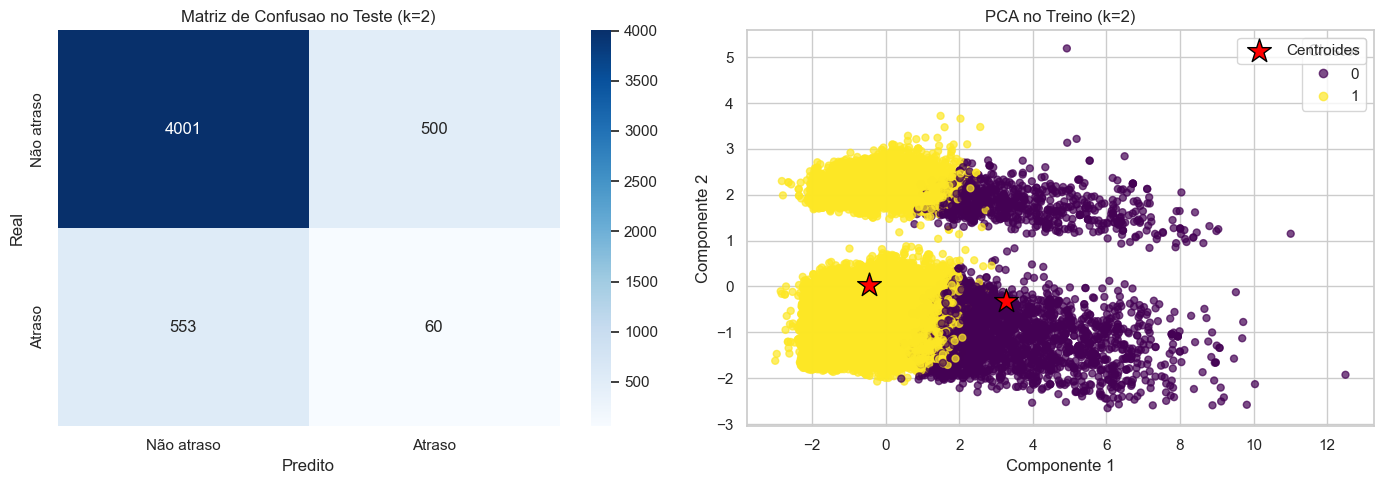

In [65]:
# Avaliacao com k=2 (Abordagem de negocio: atraso vs nao atraso)
avaliar_kmeans(
    k=2, 
    X_train=X_train_scaled, X_test=X_test_scaled, 
    y_train=y_train, y_test=y_test
)

       AVALIACAO DO MODELO KMEANS COM K = 5       

Taxa global de atraso no treino: 4.96%
Resumo por cluster:


,cluster,tamanho,taxa_atraso,regra
0,1,8246,0.0770,1
1,3,2469,0.0640,1
2,0,6556,0.0453,0
3,4,29,0.0345,0
4,2,11406,0.0293,0



Resumo final do teste:
- Accuracy: 0.6187
- Balanced Accuracy: 0.4480
- Precision atraso: 0.0850
- Recall atraso: 0.2235
- F1 atraso: 0.1232



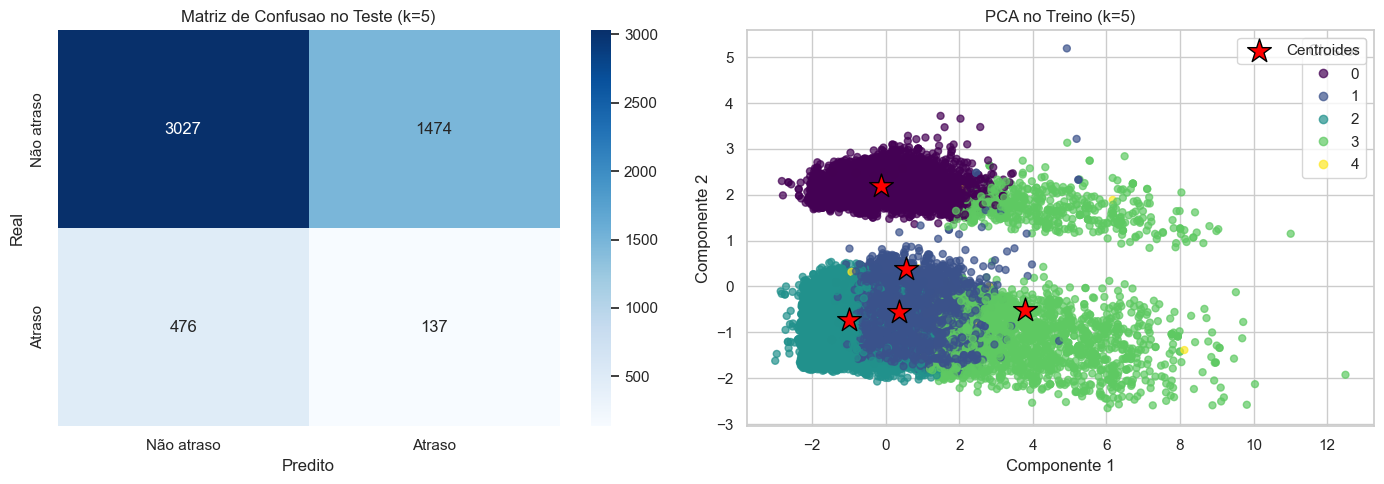

In [66]:
# Avaliacao com k do Metodo do Cotovelo
avaliar_kmeans(
    k=elbow_k, 
    X_train=X_train_scaled, X_test=X_test_scaled, 
    y_train=y_train, y_test=y_test
)